## Importación

[1.36393455 0.88058749 1.66088313 0.52073749 3.11291601 0.36870241
 2.44024584 0.59468819 0.68759417 1.57027205]


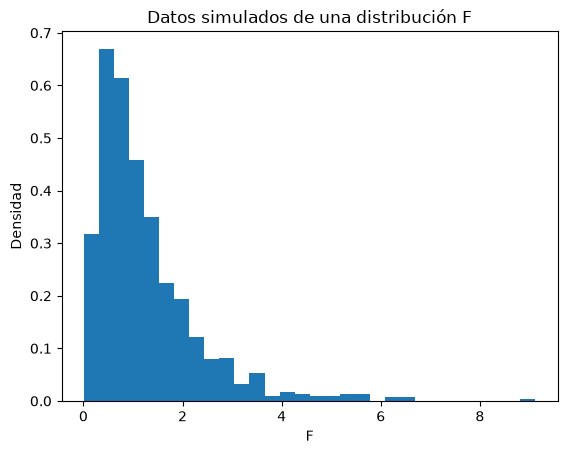

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

np.random.seed(42)

datos = f.rvs(dfn=5, dfd=10, size=1000)

print(datos[:10])

plt.hist(datos, bins=30, density=True)

plt.xlabel("F")
plt.ylabel("Densidad")
plt.title("Datos simulados de una distribución F")
plt.show()

## Parámetros de la distribución F

La distribución F tiene dos grados de libertad:

* ```dfn``` → grados de libertad del numerador
* ```dfd``` → grados de libertad del denominador

In [1]:
dfn = 5
dfd = 10

También puedes crear una distribución:

In [4]:
dist = f(dfn=dfn, dfd=dfd)

Una diferencia importante respecto a la distribución t y chi-cuadrado es que aquí necesitamos dos valores de ```df```.

## Características de la distribución F

La distribución F:

solamente toma valores positivos:
$$ X \geq 0 $$
* generalmente es asimétrica hacia la derecha;
* depende de dos grados de libertad;
* aparece principalmente en ANOVA y pruebas de comparación de varianzas.

## Visualización

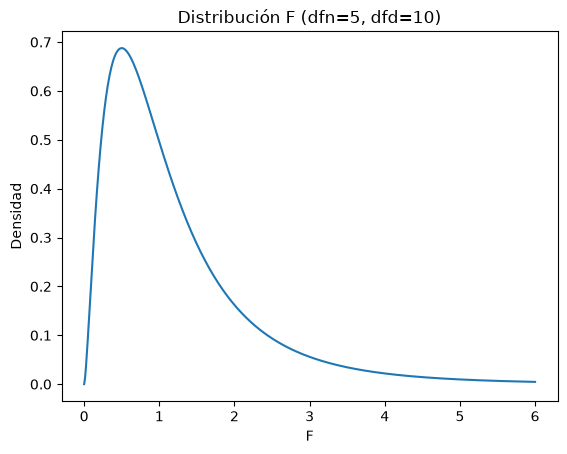

In [5]:
x = np.linspace(0, 6, 500)

pdf = f.pdf(x, dfn=dfn, dfd=dfd)

plt.plot(x, pdf)
plt.xlabel("F")
plt.ylabel("Densidad")
plt.title(f"Distribución F (dfn={dfn}, dfd={dfd})")
plt.show()

## PDF

```f.pdf()``` devuelve la densidad para un determinado valor de F.

In [6]:
f_value = 2

density = f.pdf(f_value, dfn=dfn, dfd=dfd)

print(density)

0.16200574218011515


```pdf()``` devuelve densidad, no probabilidad acumulada.

## CDF

```f.cdf()``` calcula:

$$ P(F\leq f) $$

In [7]:
f_value = 2

p = f.cdf(f_value, dfn=dfn, dfd=dfd)

print(p)

0.8358050491002611


Esto responde:

- ¿Cuál es la probabilidad de obtener un valor F menor o igual a 2?

### Probabilidad de obtener un valor mayor

Por ejemplo:

- ¿Cuál es la probabilidad de obtener un valor F mayor a 2?

In [8]:
f_value = 2

p_right = 1 - f.cdf(f_value, dfn=dfn, dfd=dfd)

print(p_right)

0.1641949508997389


Esto representa:

$$ P(F>2) $$

### Probabilidad entre dos valores

Por ejemplo:

- ¿Cuál es la probabilidad de que F esté entre 1 y 3?

In [9]:
p = (f.cdf(3, dfn=dfn, dfd=dfd)- f.cdf(1, dfn=dfn, dfd=dfd))

print(p)

0.39956186444395625


La lógica es:

$$ P(1\leq F\leq3) $$

## PPF — valor crítico

```ppf()``` permite obtener un valor de F a partir de una probabilidad acumulada.

In [10]:
probabilidad = 0.95

f_critical = f.ppf(probabilidad, dfn=dfn, dfd=dfd)

print(f_critical)

3.3258345304130104


Esto responde:

- ¿Qué valor de F deja el 95 % del área a la izquierda?

Es decir:

$$ P(F\leq F_{crítico})=0.95 $$

## Valor crítico con α = 0.05

En muchas pruebas F, la región de rechazo se encuentra en la cola derecha.

Si:

In [12]:
alpha = 0.05

f_critical = f.ppf(1 - alpha, dfn=dfn, dfd=dfd)

print(f_critical)

3.3258345304130104


La lógica es:

$$ P(F>F_{crítico})=\alpha $$

por lo tanto:

$$ P(F\leq F_{crítico})=1-\alpha $$

## P-value a partir de un estadístico F

Supongamos que después de realizar un ANOVA obtienes:

In [13]:
f_calculated = 4.83

dfn = 2
dfd = 97

Puedes obtener el p-value:

In [14]:
p_value = f.sf(f_calculated, dfn=dfn, dfd=dfd)

print(p_value)

0.010008120220495702


Esto representa:

$$ p=P(F\geq4.83) $$

Conexión con ANOVA:

```F calculado```\
     ```│```\
     ```▼```\
```f.sf()```\
     ```│```\
     ```▼```\
```p-value```

## F calculado vs F crítico

Puedes comparar ambos:

In [15]:
alpha = 0.05

f_critical = f.ppf(1 - alpha, dfn=dfn, dfd=dfd)

print("F calculado:", f_calculated)
print("F crítico:", f_critical)

F calculado: 4.83
F crítico: 3.0901866751548597


La regla es:

$$ F_{calculado}>F_{crítico} \Rightarrow \text{rechazar }H_0 $$

## Relación con ANOVA

La distribución F aparece directamente en ANOVA.

En ANOVA:

$$ F= \frac{MS_{entre}} {MS_{dentro}} $$

donde:

* ```MSentre``` → variabilidad entre grupos
* ```MSdentro``` → variabilidad dentro de los grupos

Por ejemplo:

In [17]:
MS_between = 120
MS_within = 24

F_calculated = MS_between / MS_within

print(F_calculated)

5.0


Ese ```F_calculated``` posteriormente puede compararse con la distribución F:

In [18]:
dfn = 2
dfd = 97

p_value = f.sf(F_calculated, dfn=dfn, dfd=dfd)

print(p_value)

0.008576614583886165


Esto conecta directamente:

```ANOVA```\
  ```│```\
  ```├── MS entre```\
  ```├── MS dentro```\
  ```│```\
  ```▼```\
```F calculado```\
  ```│```\
  ```▼```\
```Distribución F```\
  ```│```\
  ```├── F crítico → f.pp```\
  ```└── p-value → f.sf()```\

## Efecto de los grados de libertad

Visualizando cómo cambia la distribución dependiendo de ```dfn``` y ```dfd```.

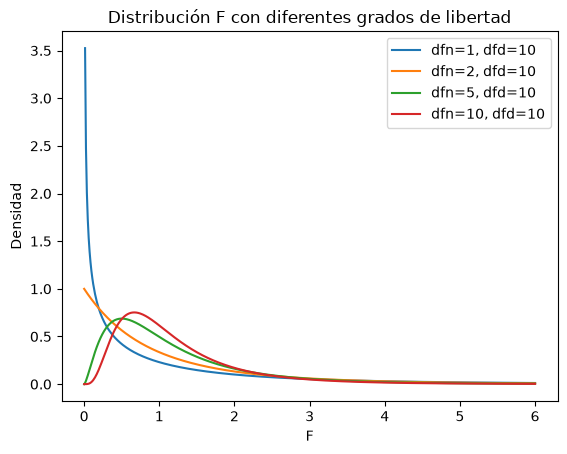

In [19]:
x = np.linspace(0, 6, 500)

for dfn, dfd in [(1, 10), (2, 10), (5, 10), (10, 10)]:
    plt.plot(x, f.pdf(x, dfn=dfn, dfd=dfd), label=f"dfn={dfn}, dfd={dfd}")

plt.xlabel("F")
plt.ylabel("Densidad")
plt.title("Distribución F con diferentes grados de libertad")
plt.legend()
plt.show()

Efecto de modificar ```dfd```:

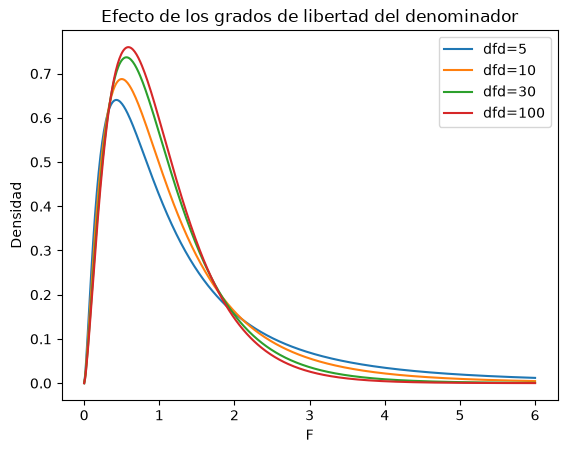

In [20]:
x = np.linspace(0, 6, 500)

for dfd in [5, 10, 30, 100]:
    plt.plot(x, f.pdf(x, dfn=5, dfd=dfd), label=f"dfd={dfd}")

plt.xlabel("F")
plt.ylabel("Densidad")
plt.title("Efecto de los grados de libertad del denominador")
plt.legend()
plt.show()

## Media y varianza

Para la distribución F, la media existe cuando:

$$ dfd>2 $$

In [21]:
dfn = 5
dfd = 10

mean = f.mean(dfn=dfn, dfd=dfd)

print("Media:", mean)

Media: 1.25


La varianza requiere:

$$ dfd>4 $$

In [22]:
variance = f.var(dfn=dfn, dfd=dfd)

print("Varianza:", variance)

Varianza: 1.3541666666666667
